# **Desafios de Visualização de Dados**

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações padrão para gráficos (para começar limpo)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

Bibliotecas importadas e configurações aplicadas!


### 1: Desafios de Decisão

Para cada cenário abaixo, você receberá um conjunto de dados e uma pergunta de negócio. Sua tarefa é:

1. Analisar a pergunta e o tipo de dado.

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

Desafio 1.1: Comparação de Vendas por Região

Cenário: Uma empresa de varejo quer comparar o desempenho de vendas de suas quatro regiões no último trimestre para identificar qual delas precisa de mais atenção.



In [55]:
# Dados para o Desafio 1.1
dados_regiao = {
    'Regiao': ['Norte', 'Sul', 'Leste', 'Oeste'],
    'Vendas_Milhoes': [12.5, 18.2, 15.0, 9.8]
}
df_regiao = pd.DataFrame(dados_regiao)
print("\nDataFrame para Desafio 1.1:")
print(df_regiao)


DataFrame para Desafio 1.1:
  Regiao  Vendas_Milhoes
0  Norte            12.5
1    Sul            18.2
2  Leste            15.0
3  Oeste             9.8


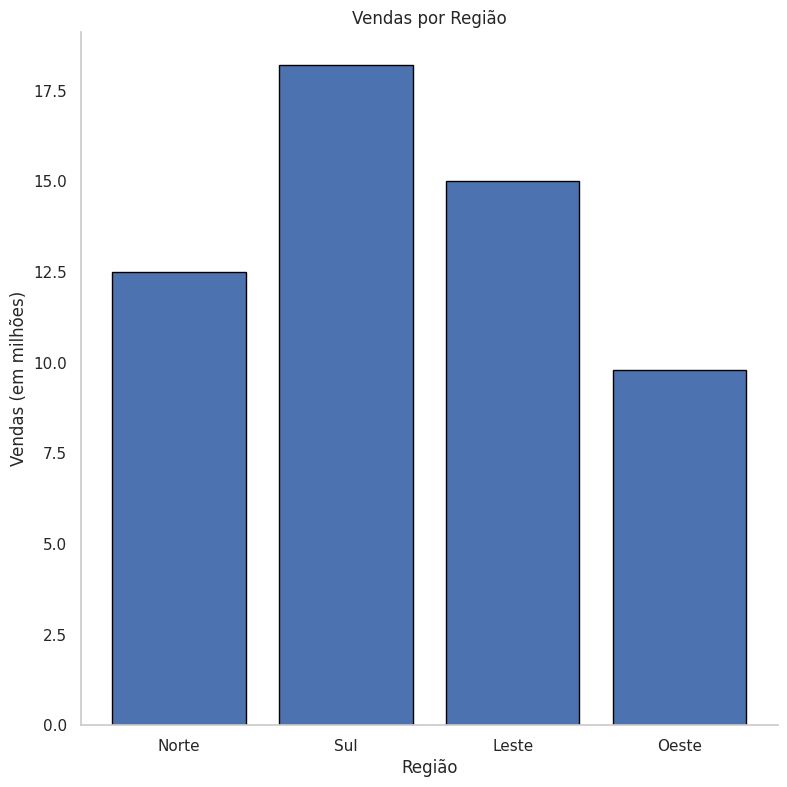

In [56]:
# Escreva sua justificativa aqui:

# 1. Tipo de gráfico escolhido: Gráfico em Barras (Barplot)

# 2. Justificativa (Cleveland-McGill, Gestalt):
# Seguindo a hierarquia de Cleveland-McGill, decidi usar o gráfico em barras pois é fácil comparar o topo de barras que possuem o mesmo eixo.
# Seguindo as leis de Gestalt, priorizei o fechamento, tirei o grid e as bordas para ter uma estrutura limpa.

# Criando o gráfico
fig, ax = plt.subplots(figsize=(9, 9))

ax.bar(df_regiao['Regiao'], df_regiao['Vendas_Milhoes'], edgecolor='black')

ax.set_title('Vendas por Região')
ax.set_xlabel('Região')
ax.set_ylabel('Vendas (em milhões)')
ax.grid(False)

plt.show()

Desafio 1.2: Distribuição de Idades de Clientes

Cenário: Uma equipe de marketing quer entender a distribuição de idade de seus clientes para segmentar campanhas. Eles têm dados de idade de 1000 clientes.

In [57]:
# Dados para o Desafio 1.2
np.random.seed(42)
idades = np.random.normal(loc=35, scale=10, size=1000).astype(int)
idades = idades[(idades >= 18) & (idades <= 70)] # Limitar idades razoáveis
df_idades = pd.DataFrame({'Idade': idades})
print("\nDataFrame para Desafio 1.2 (primeiras 5 linhas):")
print(df_idades.head())


DataFrame para Desafio 1.2 (primeiras 5 linhas):
   Idade
0     39
1     33
2     41
3     50
4     32


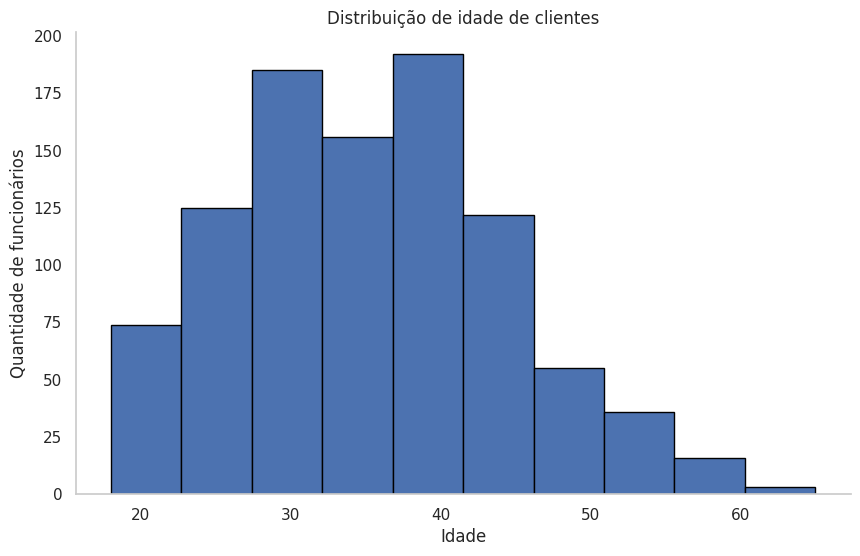

In [58]:
# Escreva sua justificativa aqui:

# 1. Tipo de gráfico escolhido: Histograma

# 2. Justificativa (Cleveland-McGill, Gestalt):
# Seguindo a hierarquia de Cleveland-McGill, priorizei por usar um histograma pois estou analizando uma posição ao longo de uma escala em comum
# Seguindo as leis de Gestalt, priorizei o fechamento, tirei o grid e as bordas para ter uma estrutura limpa.

fig, ax = plt.subplots()
ax.hist(df_idades, alpha=1.0, edgecolor='black')
ax.set_title('Distribuição de idade de clientes')
ax.set_xlabel('Idade')
ax.set_ylabel('Quantidade de funcionários')
ax.grid(False)
plt.show()

Desafio 1.3: Tendência de Acessos ao Site

Cenário: A equipe de produto quer monitorar a evolução diária do número de acessos ao site nos últimos 30 dias para identificar padrões ou quedas.

In [59]:
# Dados para o Desafio 1.3
datas = pd.date_range(start='2024-03-01', periods=30)
np.random.seed(42)
acessos = np.random.randint(1000, 5000, 30)
# Simular uma queda nos últimos dias
acessos[-5:] = np.random.randint(500, 1500, 5)
df_acessos = pd.DataFrame({'Data': datas, 'Acessos': acessos})
print("\nDataFrame para Desafio 1.3 (primeiras 5 linhas):")
print(df_acessos.head())


DataFrame para Desafio 1.3 (primeiras 5 linhas):
        Data  Acessos
0 2024-03-01     4174
1 2024-03-02     4507
2 2024-03-03     1860
3 2024-03-04     2294
4 2024-03-05     2130


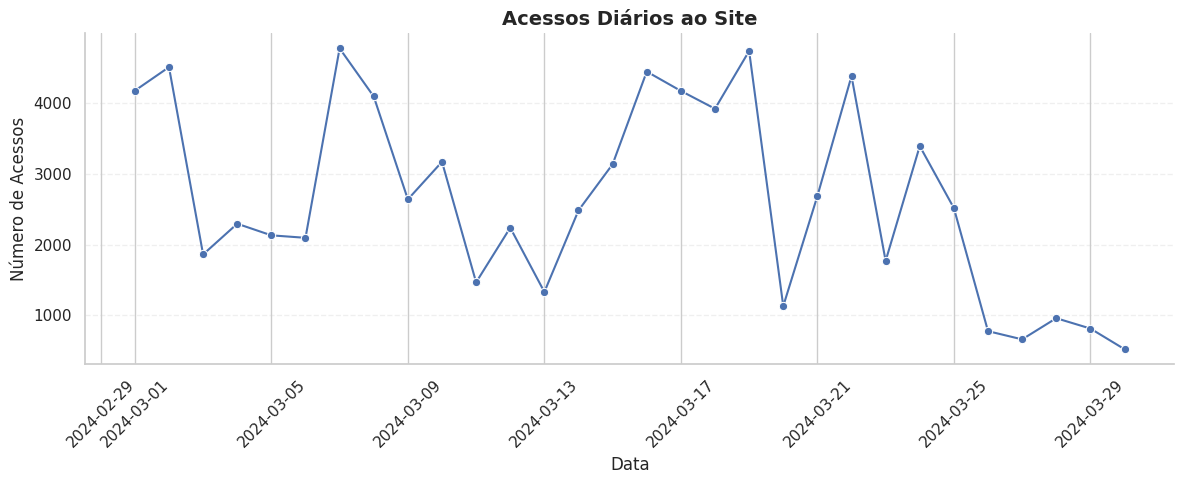

In [60]:
# Escreva sua justificativa aqui:

# 1. Tipo de gráfico escolhido: Gráfico de linhas

# 2. Justificativa (Cleveland-McGill, Gestalt):
# O gráfico de linhas é ideal para verificar variações de números ao decorrer do tempo;
# Seguindo Cleveland-McGill, a posição ao longo de uma escala comum é ideal para comparações;
# Seguindo Gestalt, podemos observar que a continuidade auxilia na leitura do gráfico, pois seguimos linhas continuas com maior facilidade.

plt.figure(figsize=(12, 5))
ax = sns.lineplot(x="Data", y="Acessos", data=df_acessos, marker='o')
ax.set_title("Acessos Diários ao Site", fontsize=14, fontweight='bold')
ax.set_xlabel("Data")
ax.set_ylabel("Número de Acessos")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Desafio 1.4: Relação entre Investimento em Marketing e Vendas

Cenário: A equipe de finanças quer entender se há uma correlação entre o investimento mensal em marketing e o volume de vendas gerado no mesmo mês.

In [61]:
# Dados para o Desafio 1.4
np.random.seed(42)
investimento_marketing = np.random.randint(10000, 50000, 12)
vendas_mensais = investimento_marketing * 5 + np.random.randint(-5000, 5000, 12)
df_marketing_vendas = pd.DataFrame({
    'Investimento_Marketing': investimento_marketing,
    'Vendas_Mensais': vendas_mensais
})
print("\nDataFrame para Desafio 1.4 (primeiras 5 linhas):")
print(df_marketing_vendas.head())


DataFrame para Desafio 1.4 (primeiras 5 linhas):
   Investimento_Marketing  Vendas_Mensais
0                   25795          129286
1                   10860           54351
2                   48158          242210
3                   21284          102604
4                   16265           80880


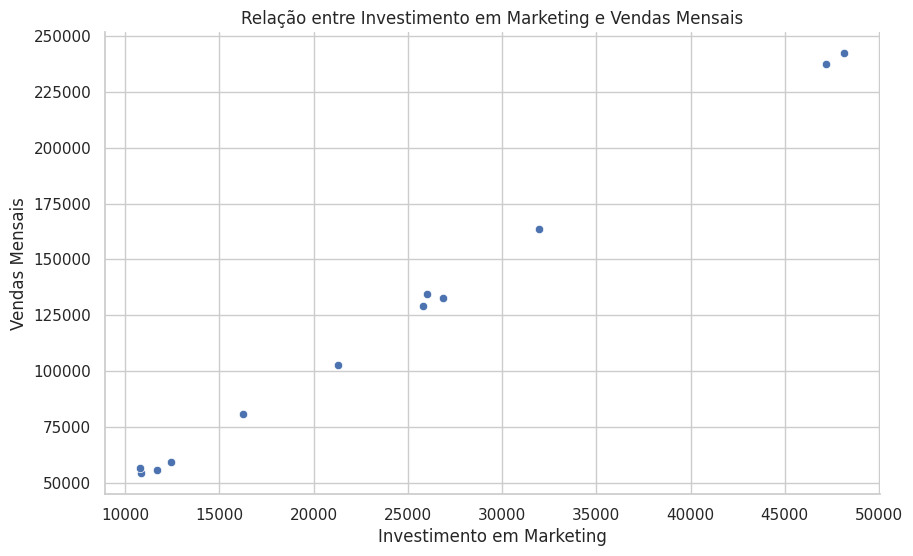

In [62]:
# Escreva sua justificativa aqui:

# 1. Tipo de gráfico escolhido: SCATTERPLOT

# 2. Justificativa (Cleveland-McGill, Gestalt):
# Seguindo Cleveland-McGill, a distribuição de pontos ao longo de uma escala comum é ideal para comparações;
# Seguindo as leis de Gestalt, a proximidade e a similaridade ajudam na percepção de agrupamentos, permitindo a identificação da relação entre investimento em marketing e vendas mensais.

sns.scatterplot(x=investimento_marketing, y=vendas_mensais)

plt.title("Relação entre Investimento em Marketing e Vendas Mensais")
plt.xlabel("Investimento em Marketing")
plt.ylabel("Vendas Mensais")
plt.show()

Desafio 1.5: Composição de Mercado por Categoria de Produto

Cenário: Um analista de mercado quer visualizar a proporção de cada categoria de produto no total de vendas da empresa para entender a dominância de certas categorias.

In [63]:
# Dados para o Desafio 1.5
dados_categorias = {
    'Categoria': ['Eletrônicos', 'Vestuário', 'Alimentos', 'Livros', 'Serviços'],
    'Vendas_Milhoes': [35.0, 20.0, 15.0, 10.0, 5.0]
}
df_categorias = pd.DataFrame(dados_categorias)
print("\nDataFrame para Desafio 1.5:")
print(df_categorias)


DataFrame para Desafio 1.5:
     Categoria  Vendas_Milhoes
0  Eletrônicos            35.0
1    Vestuário            20.0
2    Alimentos            15.0
3       Livros            10.0
4     Serviços             5.0


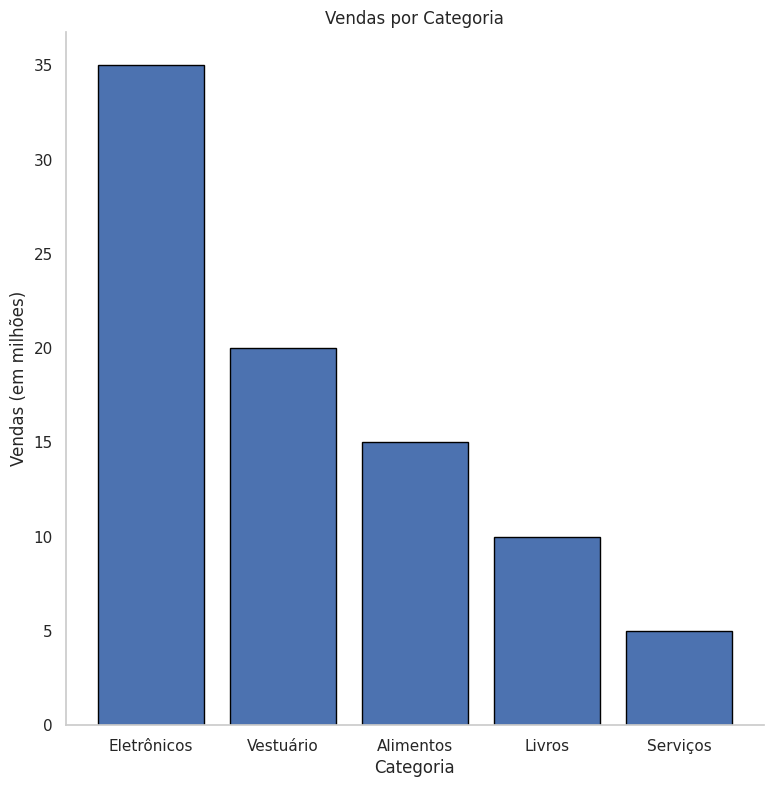

In [64]:
# Escreva sua justificativa aqui:

# 1. Tipo de gráfico escolhido: GRÁFICO EM BARRAS

# 2. Justificativa (Cleveland-McGill, Gestalt):
# Seguindo Cleveland Mcgill, comparar comprimentos em uma escala comum é mais preciso e ideal para comparações
# Seguindo Gestalt, o alinhamento e a proximidade das barras facilitam a percepção de diferenças, padrões e da dominância entre as categorias de produto.

fig, ax = plt.subplots(figsize=(9, 9))

ax.bar(df_categorias['Categoria'], df_categorias['Vendas_Milhoes'], edgecolor='black')

ax.set_title('Vendas por Categoria')
ax.set_xlabel('Categoria')
ax.set_ylabel('Vendas (em milhões)')
ax.grid(False)
plt.show()

### Parte 2: Desafios de Refatoração Crítica

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1: Vendas Trimestrais com Eixo Y Enganoso

Cenário: Um gerente de vendas recebeu este gráfico e está preocupado com uma suposta queda drástica nas vendas do Q4.

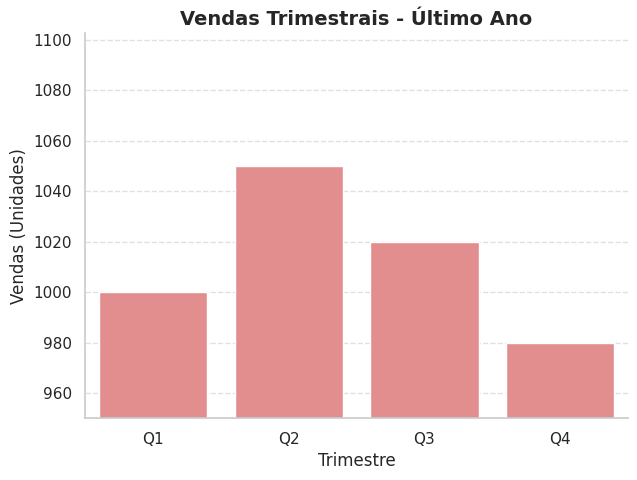

In [65]:
# Dados para o Desafio 2.1
dados_trimestrais = {
    'Trimestre': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Vendas': [1000, 1050, 1020, 980]
}
df_trimestral = pd.DataFrame(dados_trimestrais)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Trimestre', y='Vendas', data=df_trimestral, color='lightcoral')
ax.set_ylim(bottom=950) # Eixo Y começando alto
ax.set_title('Vendas Trimestrais - Último Ano', fontsize=14, fontweight='bold')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Vendas (Unidades)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

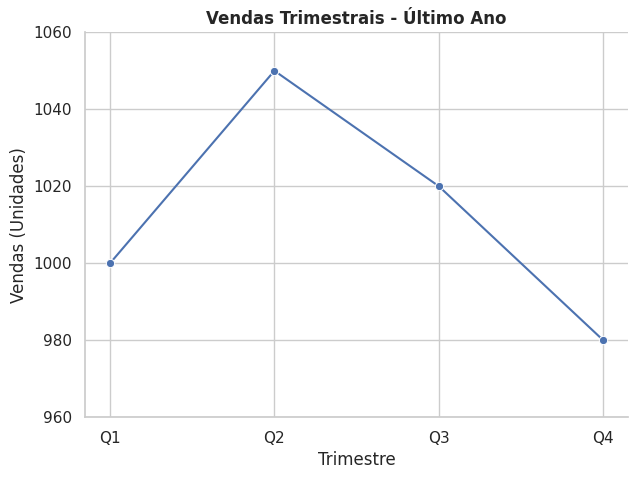

In [66]:
# 1. Problemas identificados:

#    a) Gráfico não está com eixo 0, o que o que exagera visualmente as diferenças entre os trimestres (Lie Factor / honestidade visual)
#    b) Um gráfico de linha ou pontos seria mais adequado, pois comunica melhor pequenas variações ao longo do tempo do que barras (Cleveland-McGill).
#    c) Grades e preenchimento das barras não traz nova informação, tem mais informação na cor do que na informação do gráfico em si (Data-Ink Ratio)

# 2. Seu código Python refatorado:

plt.figure(figsize=(7, 5))
ax = sns.lineplot(x="Trimestre", y="Vendas", data=df_trimestral, marker='o')

ax.set_title("Vendas Trimestrais - Último Ano", fontsize=12, fontweight='bold')
ax.set_xlabel("Trimestre")
ax.set_ylabel("Vendas (Unidades)")
ax.set_ylim(960, 1060)

plt.show()

Desafio 2.2: Comparação de Produtos com Gráfico de Pizza Lotado

Cenário: A equipe de produto quer ver a proporção de vendas de 8 produtos diferentes, mas o gráfico atual está confuso.

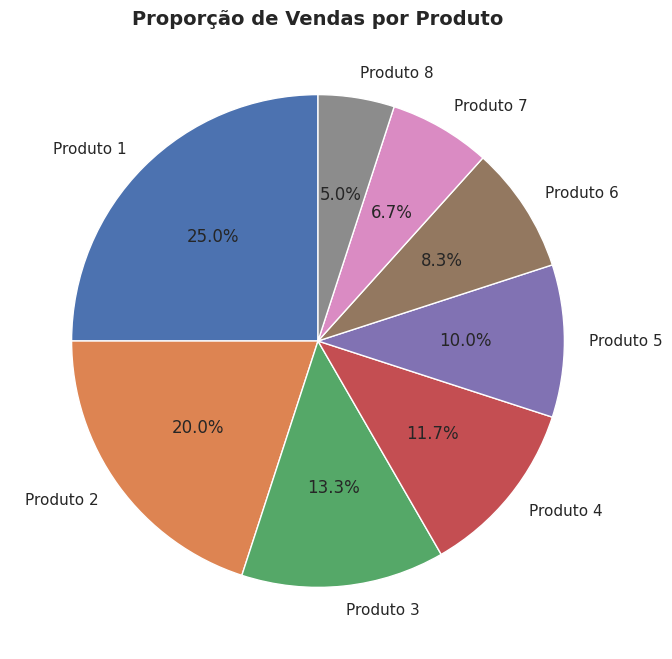

In [67]:
# Dados para o Desafio 2.2
dados_produtos = {
    'Produto': [f'Produto {i}' for i in range(1, 9)],
    'Vendas': [150, 120, 80, 70, 60, 50, 40, 30]
}
df_produtos = pd.DataFrame(dados_produtos)

plt.figure(figsize=(8, 8))
plt.pie(df_produtos['Vendas'], labels=df_produtos['Produto'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Vendas por Produto', fontsize=14, fontweight='bold')
plt.show()

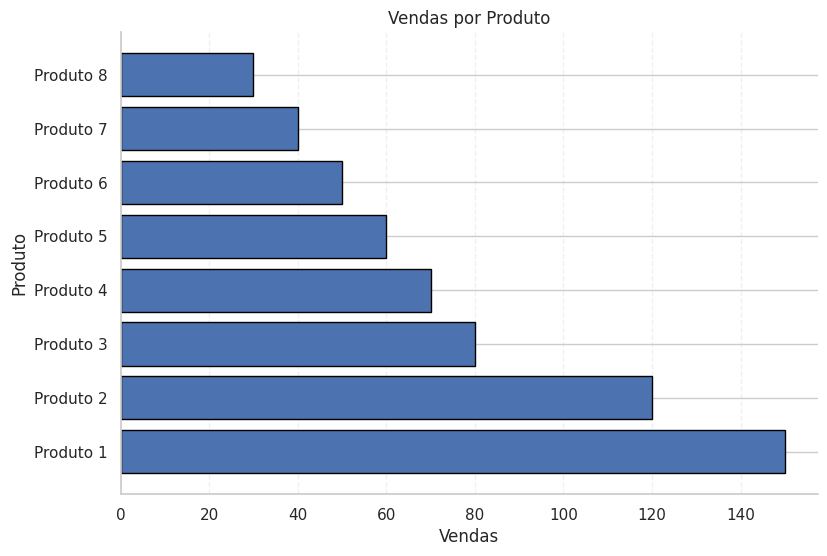

In [68]:
# 1. Problemas identificados:

#    a) No gráfico de pizza o leitor precisa comparar ângulos e áreas, o que é menos preciso do que usar um gráfico em barras por exemplo (Cleveland-McGill).
#    b) O gráfico está visualmente carregado e confuso, pois tem muitas cores e fatias, o que reduz a clareza (Chartjunk)
#    c) Algumas fatias têm tamanhos parecidos, o que dificulta perceber a diferença entre categorias.

# 2. Seu código Python refatorado:

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(df_produtos['Produto'], df_produtos['Vendas'], edgecolor='black')

ax.set_title('Vendas por Produto')
ax.set_xlabel('Vendas')
ax.set_ylabel('Produto')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()


Desafio 2.3: Desempenho de Funcionários com Cores Aleatórias

Cenário: O RH quer visualizar o desempenho (pontuação de 0 a 100) de 5 funcionários em uma avaliação, mas o gráfico atual usa cores sem sentido.

/tmp/ipykernel_7393/178950125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)


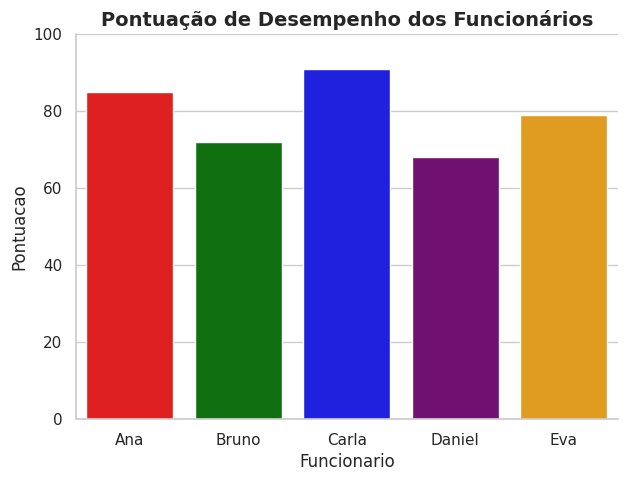

In [69]:
# Dados para o Desafio 2.3
dados_funcionarios = {
    'Funcionario': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Eva'],
    'Pontuacao': [85, 72, 91, 68, 79]
}
df_funcionarios = pd.DataFrame(dados_funcionarios)

plt.figure(figsize=(7, 5))
cores_aleatorias = ['red', 'green', 'blue', 'purple', 'orange']
ax = sns.barplot(x='Funcionario', y='Pontuacao', data=df_funcionarios, palette=cores_aleatorias)
ax.set_title('Pontuação de Desempenho dos Funcionários', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
plt.show()

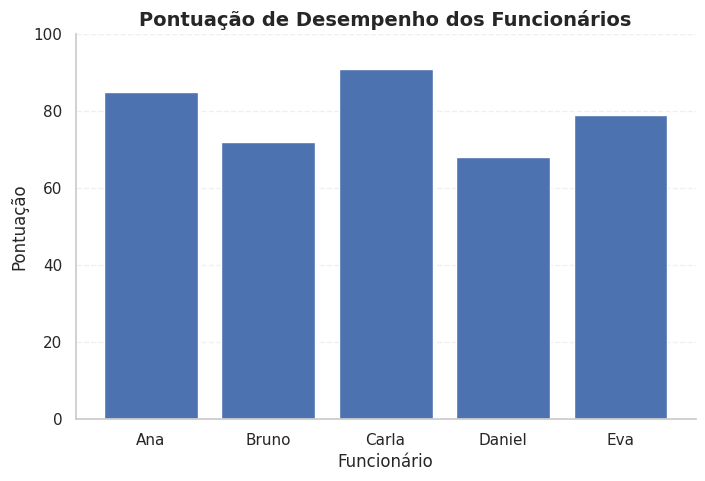

In [70]:
# 1. Problemas identificados:

#    a) O Gráfico tem muitas cores, o que tira o foco das informaçoês primordiais e reduz clareza (Chartjunk).
#    b) Como cada barra tem uma cor diferente, o leitor pode interpretar que existe alguma categoria ou grupo especial entre os funcionários, quando na verdade não há essa distinção (Gestalt - Semelhança).
#    c) Cor deveria destacar algo relevante, como maior pontuação, menor pontuação ou alguma faixa de desempenho, e não ser usada sem critério.

# 2. Seu código Python refatorado:

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(df_funcionarios['Funcionario'], df_funcionarios['Pontuacao'])

ax.set_title('Pontuação de Desempenho dos Funcionários', fontsize=14, fontweight='bold')
ax.set_xlabel('Funcionário')
ax.set_ylabel('Pontuação')
ax.set_ylim(0, 100)
ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.show()

Desafio 2.4: Gráfico de Linhas com Chartjunk Excessivo

Cenário: Um analista de dados criou este gráfico para mostrar a evolução de duas métricas ao longo do tempo, mas ele está muito poluído.

/tmp/ipykernel_7393/3038338850.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')


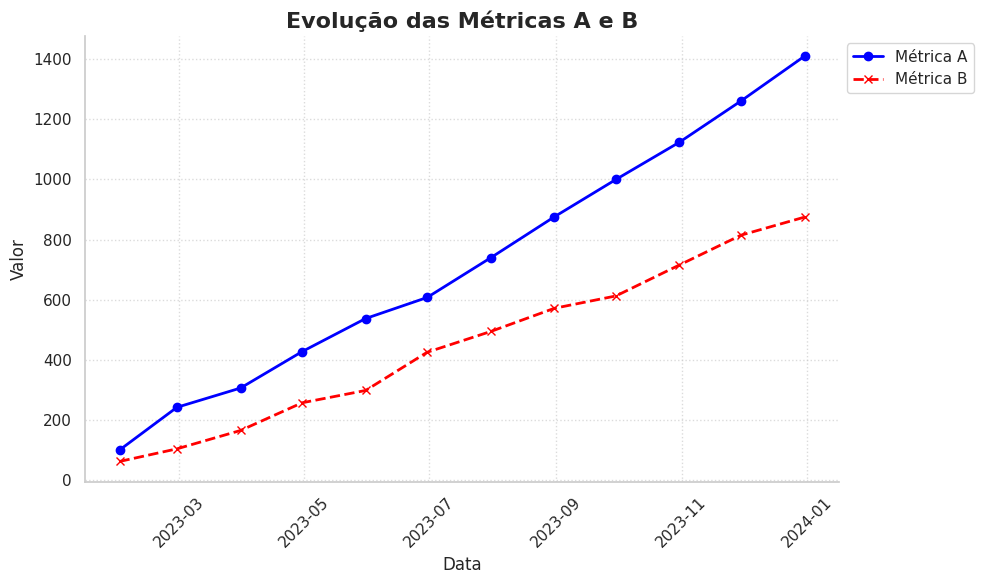

In [71]:
# Dados para o Desafio 2.4
datas_mes = pd.date_range(start='2023-01-01', periods=12, freq='M')
np.random.seed(42)
metrica_a = np.random.randint(50, 150, 12).cumsum()
metrica_b = np.random.randint(40, 130, 12).cumsum()

df_metricas = pd.DataFrame({
    'Data': datas_mes,
    'Metrica_A': metrica_a,
    'Metrica_B': metrica_b
})

plt.figure(figsize=(10, 6))
plt.plot(df_metricas['Data'], df_metricas['Metrica_A'], label='Métrica A', marker='o', linestyle='-', linewidth=2, color='blue')
plt.plot(df_metricas['Data'], df_metricas['Metrica_B'], label='Métrica B', marker='x', linestyle='--', linewidth=2, color='red')

plt.title('Evolução das Métricas A e B', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

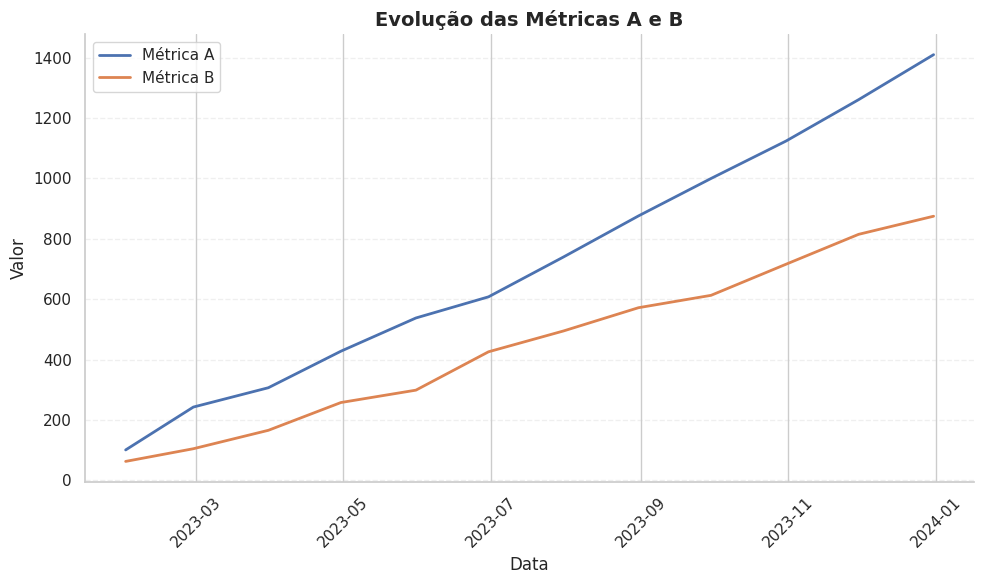

In [72]:
# 1. Problemas identificados:

#    a) As duas linhas tem o visual muito diferente, sendo que ambas se tratam de métricas, o que aumenta a poluição visual (Chartjunk)
#    b) O uso de marcadores em todos os pontos pode ser desnecessário, já que a linha já comunica a tendência ao longo do tempo. (Continuidade)
#    c) Há muitos elementos visuais, marcadores diferentes, cores fortes, linha sólida vs tracejada, grade visível e rótulos inclinado. (Data-Ink Ratio)

# 2. Seu código Python refatorado:

plt.figure(figsize=(10, 6))
ax = plt.gca()

ax.plot(df_metricas['Data'], df_metricas['Metrica_A'], label='Métrica A', linewidth=2)
ax.plot(df_metricas['Data'], df_metricas['Metrica_B'], label='Métrica B', linewidth=2)

ax.set_title('Evolução das Métricas A e B', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Valor')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Desafio 2.5: Comparação de Desempenho com Gráfico de Bolhas Confuso

Cenário: Um gerente de produto quer comparar o desempenho de diferentes funcionalidades (Funcionalidade 1 a 5) com base em duas métricas: 'Uso' e 'Satisfação'. O tamanho da bolha representa o 'Impacto'.

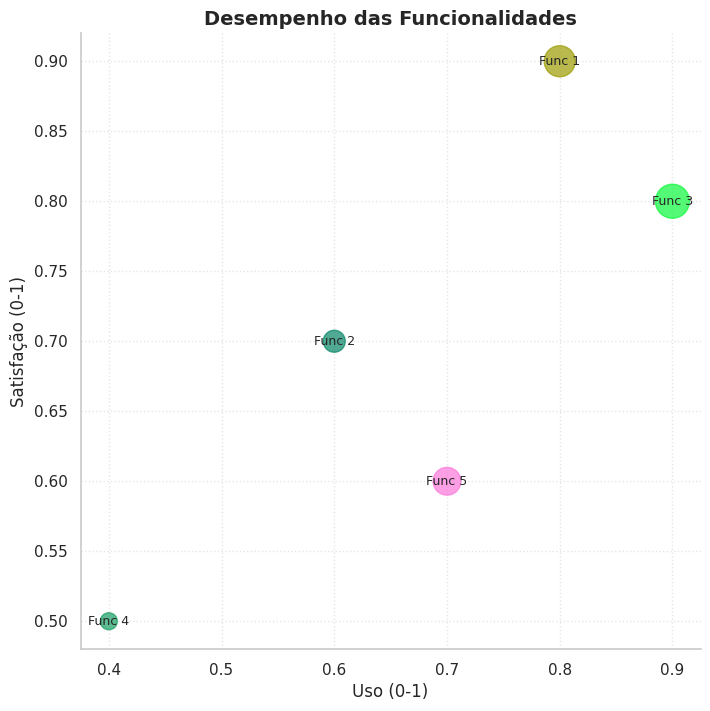

In [73]:
# Dados para o Desafio 2.5
dados_funcionalidades = {
    'Funcionalidade': [f'Func {i}' for i in range(1, 6)],
    'Uso': [0.8, 0.6, 0.9, 0.4, 0.7],
    'Satisfacao': [0.9, 0.7, 0.8, 0.5, 0.6],
    'Impacto': [100, 50, 120, 30, 80]
}
df_funcionalidades = pd.DataFrame(dados_funcionalidades)

plt.figure(figsize=(8, 8))
plt.scatter(x=df_funcionalidades['Uso'], y=df_funcionalidades['Satisfacao'],
            s=df_funcionalidades['Impacto']*5, # Multiplicar para bolhas maiores
            alpha=0.7,
            c=np.random.rand(len(df_funcionalidades), 3)) # Cores aleatórias

for i, row in df_funcionalidades.iterrows():
    plt.text(row['Uso'], row['Satisfacao'], row['Funcionalidade'], fontsize=9, ha='center', va='center')

plt.title('Desempenho das Funcionalidades', fontsize=14, fontweight='bold')
plt.xlabel('Uso (0-1)', fontsize=12)
plt.ylabel('Satisfação (0-1)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

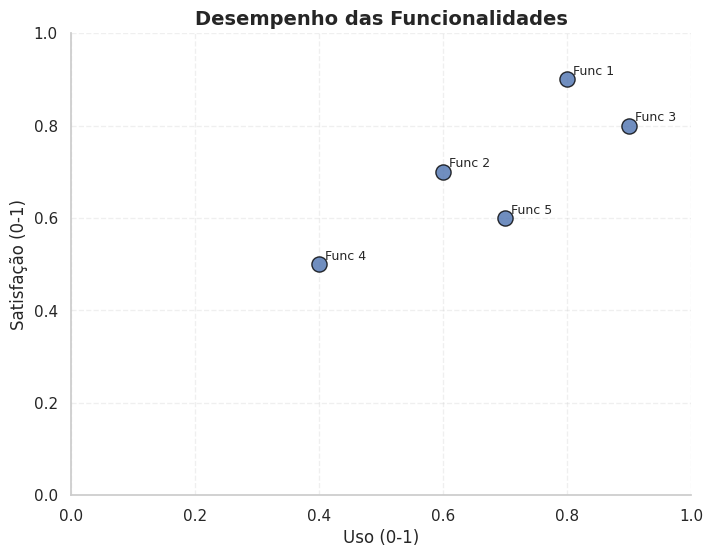

In [84]:
# 1. Problemas identificados:
#    a) O uso de cores aleatórias não comunica nenhuma categoria ou agrupamento, apenas adiciona ruído visual e reduz a clareza (Chartjunk / Gestalt - semelhança).
#    b) O tamanho das bolhas representa o impacto por área, e comparar áreas é menos preciso do que comparar posições em escala comum (Cleveland-McGill).
#    c) Os rótulos foram colocados dentro das bolhas, o que atrapalha a leitura.

# 2. Seu código Python refatorado:

plt.figure(figsize=(8, 6))
ax = plt.gca()

ax.scatter(
    df_funcionalidades['Uso'],
    df_funcionalidades['Satisfacao'],
    s=120,
    alpha=0.8,
    edgecolor='black'
)

for i, row in df_funcionalidades.iterrows():
    ax.text(
        row['Uso'] + 0.01,
        row['Satisfacao'] + 0.01,
        row['Funcionalidade'],
        fontsize=9
    )

ax.set_title('Desempenho das Funcionalidades', fontsize=14, fontweight='bold')
ax.set_xlabel('Uso (0-1)')
ax.set_ylabel('Satisfação (0-1)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()